In [29]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [30]:
train_dir = "datadir/train"
test_dir = "datadir/test"

In [31]:
img_height = 48
img_width = 48
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.


In [32]:
class_names = train_ds.class_names
print("Class names:", class_names)

Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [33]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [34]:
num_classes = len(class_names)

model = models.Sequential([
    layers.Input(shape=(48, 48, 1)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')
])

In [35]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [37]:
epochs = 15

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=epochs
)

Epoch 1/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 173s 152ms/step - accuracy: 0.3260 - loss: 1.6799 - val_accuracy: 0.4267 - val_loss: 1.4961
Epoch 2/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 189s 173ms/step - accuracy: 0.4433 - loss: 1.4439 - val_accuracy: 0.4787 - val_loss: 1.3430
Epoch 3/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 147s 163ms/step - accuracy: 0.4934 - loss: 1.3310 - val_accuracy: 0.5022 - val_loss: 1.2849
Epoch 4/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 144s 160ms/step - accuracy: 0.5259 - loss: 1.2541 - val_accuracy: 0.5283 - val_loss: 1.2442
Epoch 5/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 131s 146ms/step - accuracy: 0.5471 - loss: 1.1948 - val_accuracy: 0.5386 - val_loss: 1.2075
Epoch 6/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 125s 140ms/step - accuracy: 0.5666 - loss: 1.1485 - val_accuracy: 0.5436 - val_loss: 1.1907
Epoch 7/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 132s 147ms/step - accuracy: 0.5840 - loss: 1.1055 - val_accuracy: 0.5548 - val_loss: 1.1852
Epoch 8/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 127s 141ms/step - accuracy: 0.5967 -

In [38]:
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.5595 - loss: 1.2857
Test Loss: 1.285746693611145
Test Accuracy: 0.5594873428344727


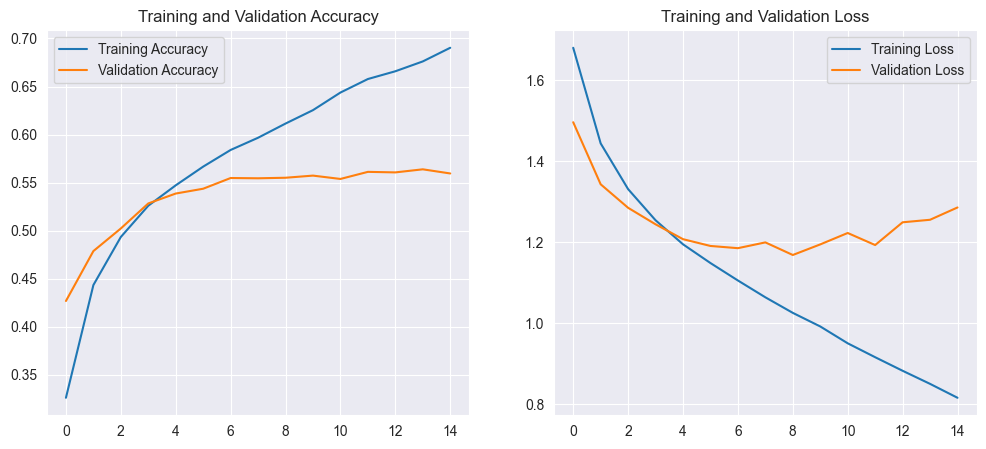

In [39]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
Prediction probabilities: [[2.8812201e-06 1.4641657e-09 2.3465559e-06 9.9964309e-01 3.1423187e-04
  9.5521827e-06 2.7936328e-05]]
Predicted emotion: happy


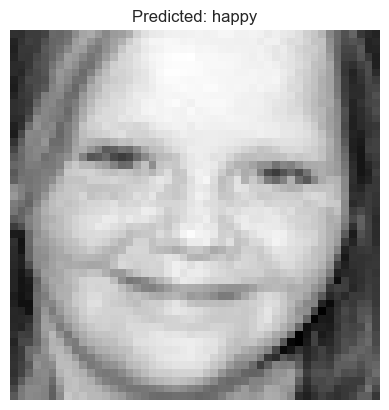

In [40]:
img_path = "datadir/test/happy/PrivateTest_9507188.jpg"

img = Image.open(img_path).convert("L")
img = img.resize((48, 48))

img_array = np.array(img)
img_array = np.expand_dims(img_array, axis=-1)   # make shape (48,48,1)
img_array = np.expand_dims(img_array, axis=0)    # make shape (1,48,48,1)

prediction = model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

print("Prediction probabilities:", prediction)
print("Predicted emotion:", predicted_class)

plt.imshow(img_array[0].squeeze(), cmap="gray")
plt.title(f"Predicted: {predicted_class}")
plt.axis("off")
plt.show()

In [41]:
model.save("fer2013_emotion_cnn.h5")
print("Model saved successfully.")
# Load model
# from tensorflow.keras.models import load_model
# model = load_model("fer2013_emotion_cnn.h5")

Model saved successfully.
